# BME i9400 — Meeting 1
## Course Launch and Course Tools

**Fall 2026 · Monday, August 31 · asynchronous**

I am at a meeting in DC today, so there is no live lecture. Work through this notebook on your
own — it is written to be self-contained.

**How to work through it.** Read each section in order and run every code cell as you reach
it (`Shift + Enter`). Do not skip the code cells: later ones use variables that earlier ones
set, so running them out of order will produce errors.

Today is all about **tools**. We are not doing any machine learning yet.

**By the end of this notebook you will have:**

1. A working Python environment in your browser (Google Colab)
2. A GitHub account
3. GitHub Desktop installed, and a copy of the course repository on your own machine
4. Made your first commit and pushed it — your first "homework"

---
## Step 0 — Save your own copy

**Do this before you run or type anything.**

> `File ▸ Save a copy in Drive`

You are currently looking at a read-only course notebook. If you start editing this one, your work
will not be saved. After you save a copy, the tab title will change to *Copy of ...* — work there.

Everything you do for the rest of this notebook happens in **your copy**.

---
# Part 1 — Google Colab

Colab is a free Google service that runs Python notebooks in your browser on Google's machines. It
is the required runtime for this course, for two reasons: there is nothing to install, and every
student is running the same environment.

A **notebook** is a document made of *cells*. Text cells (like this one) hold formatted notes.
Code cells hold Python and can be executed, with their output appearing directly underneath.

**The three things to know right now:**

| | |
|---|---|
| `Shift + Enter` | run the current cell and move to the next |
| `Ctrl/Cmd + Enter` | run the current cell and stay put |
| `Runtime ▸ Restart session` | fixes the majority of "but it worked yesterday" problems |

Run the cell below. It confirms Colab is working and prints the versions of the libraries we will use
all semester. Some of these values get recorded in your check-in at the end, so don't skip it.

In [1]:
import sys, platform, importlib, importlib.util
from datetime import datetime, timezone

try:
    IN_COLAB = ("google.colab" in sys.modules
                or importlib.util.find_spec("google.colab") is not None)
except Exception:
    IN_COLAB = False   # find_spec raises if the parent package is absent

print("Running in Colab :", IN_COLAB)
print("Python           :", sys.version.split()[0])
print("Platform         :", platform.platform())
print()

ENV = {"in_colab": bool(IN_COLAB), "python": sys.version.split()[0]}
for pkg in ["numpy", "pandas", "matplotlib", "sklearn"]:
    try:
        m = importlib.import_module(pkg)
        ENV[pkg] = getattr(m, "__version__", "?")
    except Exception as e:
        ENV[pkg] = f"MISSING ({e.__class__.__name__})"
    print(f"{pkg:12s} : {ENV[pkg]}")

ENV["run_utc"] = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
print("\nTimestamp        :", ENV["run_utc"])

if not IN_COLAB:
    print("\nNOTE: you are not in Colab. That is allowed but unsupported —")
    print("all graded work in this course assumes Colab.")

Running in Colab : True
Python           : 3.13.15
Platform         : Linux-6.6.122+-x86_64-with-glibc2.35

numpy        : 2.1.3
pandas       : 2.2.3
matplotlib   : 3.10.0
sklearn      : 1.6.1

Timestamp        : 2026-08-31 18:20 UTC


### Two things about Colab

**1. Cells run in the order *you* run them, not top to bottom.** If you run a cell, scroll up, change
something, and run a cell below it, Python remembers whatever you did most recently. The number in
`[ ]` beside each cell is the order it actually ran in. When results stop making sense, the fix is
almost always `Runtime ▸ Restart session and run all`.

**2. Your files are temporary.** Colab gives you a fresh virtual machine that is thrown away after a
period of inactivity. Anything you download or create inside it disappears with it. Your *notebook*
is safe in Google Drive; files the notebook creates are not.

Run the cell below.

In [2]:
x = 99
print("x is", x)

# Now change 10 to 99 in the line above, re-run this cell, and watch the [ ] number climb.
# The number is the execution counter — it tells you the order cells actually ran in,
# which is the single most useful debugging clue in a notebook.

x is 99


### Colab resources

- [Welcome to Colab](https://colab.research.google.com/notebooks/intro.ipynb) — the official 5-minute introduction
- [Overview of Colab features](https://colab.research.google.com/notebooks/basic_features_overview.ipynb) — cells, magics, forms, keyboard shortcuts
- [Colab FAQ](https://research.google.com/colaboratory/faq.html) — resource limits and what "free" actually means

---
# Part 2 — Python for data science

This course assumes that you can write basic Python. Below is a list of optional resources that you may consult to ramp up or refresh your Python knowledge.

### Python Basics

| Resource | Why this one |
|---|---|
| [Software Carpentry — Programming with Python](https://swcarpentry.github.io/python-novice-inflammation/) | Built for researchers, not software engineers. Uses a real scientific dataset throughout. |
| [Kaggle Learn — Python](https://www.kaggle.com/learn/python) | Short, runs in the browser, no setup. Good if you want practice rather than reading. |

### Data Science in Python

| Resource | Why this one |
|---|---|
| [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/) — Jake VanderPlas | Free reference for NumPy, pandas, and matplotlib. Entire book online as notebooks. **If you read one thing, read chapters 2 and 3.** |
| [NumPy: the absolute basics for beginners](https://numpy.org/doc/stable/user/absolute_beginners.html) | Official, short, and the fastest way to understand arrays. |
| [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html) | Official tour of dataframes. Takes forty minutes. |
| [Kaggle Learn — Pandas](https://www.kaggle.com/learn/pandas) | Hands-on drilling of the same material. |
| [Scientific Python Lectures](https://lectures.scientific-python.org/) | Broader and more rigorous, including SciPy. Good if you want depth. |
| [Matplotlib pyplot tutorial](https://matplotlib.org/stable/tutorials/pyplot.html) | Official. Visualization of data is a valuable skill. |

**All of these resources are optional**

The cell below demonstrates numpy (arrays), pandas (tables of data, much like spreadsheets but more powerful), and matplotlib (plotting).

  time_s  amplitude
0.000000   0.000000
0.002004   0.100562
0.004008   0.200105

500 samples, amplitude range [-1.00, 1.00]


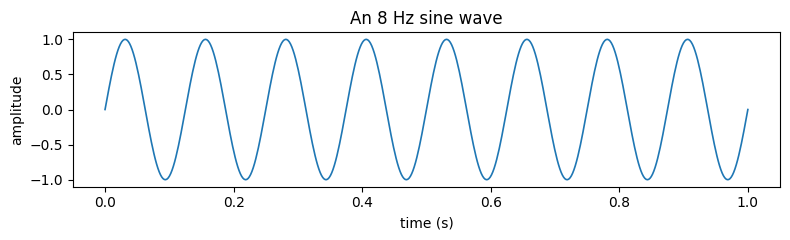

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NumPy: fast numerical arrays
t = np.linspace(0, 1, 500)                 # 500 evenly spaced time points, 0 to 1 second
signal = np.sin(2 * np.pi * 8 * t)         # an 8 Hz sine wave

# pandas: labelled tables
df = pd.DataFrame({"time_s": t, "amplitude": signal})
print(df.head(3).to_string(index=False))
print(f"\n{len(df)} samples, amplitude range [{df.amplitude.min():.2f}, {df.amplitude.max():.2f}]")

# matplotlib: figures
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(df.time_s, df.amplitude, lw=1.2)
ax.set_xlabel("time (s)"); ax.set_ylabel("amplitude")
ax.set_title("An 8 Hz sine wave")
plt.tight_layout(); plt.show()

---
# Part 3 — Git and GitHub

**Git** is a version control system. It records snapshots of a folder over time, so you can see what
changed, when, and why — and go back. It runs on your own machine and needs no internet.

**GitHub** is a website that hosts git repositories so they can be shared. Git is the tool; GitHub is
the place.

**Why you should care**, beyond this course: essentially all scientific code is now shared this way.
Journals increasingly require a repository link. When you apply for a postdoc or an industry job in
anything computational, someone will look at your GitHub.

### The vocabulary

| Term | What it means |
|---|---|
| **repository** (repo) | A folder that git is tracking, along with its entire history |
| **clone** | Download a copy of a repo onto your machine, history and all |
| **commit** | A saved snapshot, with a message describing what changed |
| **push** | Send your commits up to GitHub |
| **pull** | Bring down commits other people have pushed |
| **fork** | Your own copy of somebody else's repo, under your account |
| **pull request** (PR) | A request to merge your changes into someone else's repo |


### GitHub Desktop

You can drive git from the command line, and eventually you should. But the concepts are much easier
to see in a graphical client, where you can watch your changes appear and click *Commit*. We will
use **GitHub Desktop**, which is free and made by GitHub.

**[Download GitHub Desktop](https://desktop.github.com/)** — macOS and Windows. Please install this.

*Linux users:* GitHub Desktop is not officially supported. Use the command line, or the community
build at [github.com/shiftkey/desktop](https://github.com/shiftkey/desktop).

### Git and GitHub resources

| Resource | Why this one |
|---|---|
| [GitHub — Hello World](https://docs.github.com/en/get-started/start-your-journey/hello-world) | The official 10-minute first walkthrough. Start here. |
| [Getting started with GitHub Desktop](https://docs.github.com/en/desktop/overview/getting-started-with-github-desktop) | Official documentation for the client we are using. |
| [GitHub Skills](https://skills.github.com/) | Free interactive courses that run inside real repositories. |
| [Software Carpentry — Version Control with Git](https://swcarpentry.github.io/git-novice/) | Written for researchers. The best conceptual explanation of *why* git works the way it does. |
| [Pro Git](https://git-scm.com/book/en/v2) | The complete free book. A reference, not a tutorial. |
| [Dangit, Git!?!](https://dangitgit.com/) | Plain-language fixes for the specific mess you are currently in. Bookmark it now; you will need it. |

---
# Part 4 — Your check-in assignment

**Due at 11:59 PM EST on Wednesday September 2.**

You are going to make a few edits to this notebook, then get it into the course repository using
git. Four steps.

## Step 1 — Create a GitHub account

Skip if you already have one; you do not need a second account for this course.

Go to **[github.com/signup](https://github.com/signup)**.

## Step 2 — Fork the course repository, then clone it

**Fork it.** Go to **[github.com/dmochow/BME-i9400-2026](https://github.com/dmochow/BME-i9400-2026)**
and click **Fork** (top right), then **Create fork**. You now have your own complete copy at
`github.com/YOUR-USERNAME/BME-i9400-2026`.

> Why fork? You do not have permission to write directly to my repository. You work in your copy
> and then *propose* your changes back to me.

**Clone it.** Open GitHub Desktop and sign in. Then:

> `File ▸ Clone repository ▸ GitHub.com`, choose **your fork**, pick where to put it, and click **Clone**.

You now have the whole course repository as an ordinary folder on your machine. Find it in Finder or
File Explorer and look — it's just a folder. Git's history lives in a hidden `.git` folder alongside them.

## Step 3 — Make your edits

Fill in the three cells below, then run them. This is the "student-specific" part — everyone's
notebook will end up different.

In [4]:
# ---- Who you are -------------------------------------------------------------
NAME            = "Bruce Kapp"      # e.g. "Ada Lovelace"
EMAIL           = "BRUCE.KAPP41@stu-mail.ccny.cuny.edu"      # your @citymail.cuny.edu address
GITHUB_USERNAME = "brucekapp6-lab"      # the username you created in Step 1
# ------------------------------------------------------------------------------

for field, value in [("NAME", NAME), ("EMAIL", EMAIL), ("GITHUB_USERNAME", GITHUB_USERNAME)]:
    assert value.strip(), f"{field} is still empty — fill it in and re-run this cell."

print(f"{NAME} <{EMAIL}>")
print(f"github.com/{GITHUB_USERNAME}")

Bruce Kapp <BRUCE.KAPP41@stu-mail.ccny.cuny.edu>
github.com/brucekapp6-lab


In [5]:
# ---- Where you are starting from ---------------------------------------------
# How comfortable are you with Python today?  1 = never used it, 5 = very comfortable
PYTHON_COMFORT = 2

# Have you used git or GitHub before?  "no", "a little", or "yes"
GIT_EXPERIENCE = "no"

# What kind of data do you work with, or expect to work with, in your research?
# One or two sentences. If you don't know yet, say that — it's a fine answer.
MY_DATA = "I expect to work with fluid flow data."

# What do you want to be able to do by December that you can't do now?
# One or two sentences.
MY_GOAL = "Analyze fluid flow data more effectively and efficiently."
# ------------------------------------------------------------------------------

assert PYTHON_COMFORT in (1, 2, 3, 4, 5), "PYTHON_COMFORT must be a number from 1 to 5."
assert GIT_EXPERIENCE.strip().lower() in ("no", "a little", "yes"), \
    'GIT_EXPERIENCE must be "no", "a little", or "yes".'
for field, value in [("MY_DATA", MY_DATA), ("MY_GOAL", MY_GOAL)]:
    assert len(value.strip()) >= 25, f"{field} looks empty or very short — give it a real sentence."

print("Recorded. Thank you — I read all of these.")

Recorded. Thank you — I read all of these.


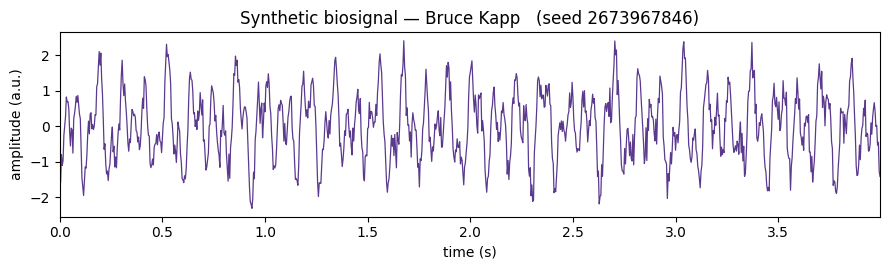

Component frequencies: 5.97 Hz, 8.77 Hz, 18.29 Hz


In [6]:
# ---- Your notebook's fingerprint ---------------------------------------------
# This makes a synthetic biosignal seeded by your name, so no two students in the
# class will produce the same figure. It is also a gentle preview of the kind of
# data we will work with. Just run it.

import hashlib
import numpy as np
import matplotlib.pyplot as plt

# A stable seed from your name. (Python's built-in hash() is randomised per
# session, so we use sha256 instead to get the same answer every time.)
seed = int(hashlib.sha256(NAME.strip().lower().encode()).hexdigest(), 16) % (2**32)
rng  = np.random.default_rng(seed)

fs, dur = 250, 4                                  # 250 Hz sampling, 4 seconds
t = np.arange(0, dur, 1 / fs)

# Three oscillations at person-specific frequencies, plus measurement noise
signal = np.zeros_like(t)
bands  = [(2, 6), (7, 12), (13, 20)]                  # slow, middle, fast
freqs  = np.array([rng.uniform(lo, hi) for lo, hi in bands])
for f, amp in zip(freqs, rng.uniform(0.5, 1.0, size=3)):
    signal += amp * np.sin(2 * np.pi * f * t + rng.uniform(0, 2 * np.pi))
signal += rng.normal(0, 0.25, size=t.size)

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(t, signal, lw=0.9, color="#5b3a8e")
ax.set_xlabel("time (s)"); ax.set_ylabel("amplitude (a.u.)")
ax.set_title(f"Synthetic biosignal — {NAME}   (seed {seed})")
ax.margins(x=0)
plt.tight_layout(); plt.show()

print(f"Component frequencies: {', '.join(f'{f:.2f} Hz' for f in sorted(freqs))}")
ENV["seed"] = int(seed)
ENV["freqs"] = [round(float(f), 2) for f in sorted(freqs)]

In [7]:
# ---- Final check -------------------------------------------------------------
# Run this last. It confirms everything is filled in and tells you your filename.

summary = f"""
  Name              {NAME}
  Email             {EMAIL}
  GitHub            @{GITHUB_USERNAME}
  Python comfort    {PYTHON_COMFORT}/5
  Git experience    {GIT_EXPERIENCE}
  Colab             {ENV['in_colab']}   Python {ENV['python']}
  Libraries         numpy {ENV['numpy']} · pandas {ENV['pandas']} · matplotlib {ENV['matplotlib']}
  Signal seed       {ENV['seed']}
  Run at            {ENV['run_utc']}
"""
print("=" * 72)
print(summary)
print("=" * 72)
print(f"\nYour file must be named:   {GITHUB_USERNAME}.ipynb")
print(f"and placed in the folder:  checkins/")
print("\nNow go to Step 4 below.")


  Name              Bruce Kapp
  Email             BRUCE.KAPP41@stu-mail.ccny.cuny.edu
  GitHub            @brucekapp6-lab
  Python comfort    2/5
  Git experience    no
  Colab             True   Python 3.13.15
  Libraries         numpy 2.1.3 · pandas 2.2.3 · matplotlib 3.10.0
  Signal seed       2673967846
  Run at            2026-08-31 18:20 UTC


Your file must be named:   brucekapp6-lab.ipynb
and placed in the folder:  checkins/

Now go to Step 4 below.


## Step 4 — Commit and push

Now we move your edited notebook into the repository and record it with git.

**1. Run every cell, top to bottom.** `Runtime ▸ Restart session and run all`. Your saved outputs —
including your figure — are part of what you are submitting, so they need to be there.

**2. Download the notebook.**

> `File ▸ Download ▸ Download .ipynb`

**3. Rename it** to `YOUR-GITHUB-USERNAME.ipynb` (exactly what the cell above printed), and move it
into the `checkins/` folder inside the repository folder you cloned in Step 2.

**4. Commit it.** Switch to GitHub Desktop. Your new file appears in the left-hand panel — this is
git noticing the folder changed. At the bottom left, write a summary such as
`Add Meeting 1 check-in` and click **Commit to main**.

> You have just made a commit: a permanent, labelled snapshot. It is on your machine only.

**5. Push it.** Click **Push origin** at the top. Your commit is now on GitHub, in your fork.

**6. Open a pull request.** GitHub Desktop will show a **Preview Pull Request** button — or go to
your fork on github.com and click **Contribute ▸ Open pull request**. Title it
`Meeting 1 check-in — Your Name` and click **Create pull request**.

**Done.** You have written code, versioned it, published it, and proposed it to a shared repository.
That's the entire workflow of modern computational research.

---

### If you get stuck

The most common problems, in the order they happen:

| Symptom | Fix |
|---|---|
| GitHub Desktop shows no changes | The file is not inside the cloned folder, or not inside `checkins/`. Check the path carefully. |
| "Push rejected" / "no write access" | You cloned *my* repo instead of *your fork*. Re-clone from your fork. |
| Cannot find the downloaded notebook | Check your browser's Downloads folder. |
| Notebook is named `Copy of ...` | Rename it to exactly `YOUR-USERNAME.ipynb`. |

*Already comfortable with git?* Colab can commit straight to GitHub via
`File ▸ Save a copy in GitHub`, and you are welcome to use it — but do Step 2 first so you have a
local clone, because we will use it repeatedly this term.
